In [1]:
# Project-relative paths: no machine-specific absolute paths are required.
from pathlib import Path

PROJECT_ROOT = Path.cwd().resolve()
for _candidate in (PROJECT_ROOT, *PROJECT_ROOT.parents):
    if (_candidate / "workspace" / "Source_Data.xlsx").exists():
        PROJECT_ROOT = _candidate
        break
else:
    raise FileNotFoundError(
        "workspace/Source_Data.xlsx was not found. Run the notebook from inside the repository."
    )

WORKSPACE_DIR = PROJECT_ROOT / "workspace"
(WORKSPACE_DIR / "figures").mkdir(parents=True, exist_ok=True)
(WORKSPACE_DIR / "figures_R3").mkdir(parents=True, exist_ok=True)

clean_data_path = WORKSPACE_DIR.as_posix().rstrip("/") + "/"
clean_data_path_yy = clean_data_path
clean_data_path_wzj = clean_data_path
clean_data_path_zzh = clean_data_path
path = clean_data_path
show_dir = clean_data_path

import numpy as np 
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib
import warnings
import pandas as pd
from scipy.stats import kruskal, wilcoxon
from statsmodels.stats.multitest import multipletests
import seaborn as sns
from scipy.stats import mannwhitneyu
import warnings
warnings.filterwarnings('ignore')



HS_list = [45, 47,  48,  50,  54, 71, 73,  76, 78]
matplotlib.rcParams['font.sans-serif'] = ['Arial']
matplotlib.rcParams['font.size'] = 6

plt.rcParams['axes.unicode_minus'] = False 

map_dict = {
    'beta1':'b1',
    'high_gamma':'hg',
    'hgb1':'b1hg'
}

In [2]:
def acc_violin_plot(band, group, mean_acc_df, param, sheet_name):
    # =====================================================
    # Reconstruct chance-level accuracy values.
    # =====================================================
    
    test_df = mean_acc_df.copy()
    
    HS_list = sorted(test_df["HS"].unique())
    
    for HS in HS_list:
    
        chance = 1 / 6 if HS < 70 else 1 / 8
    
        test_df = pd.concat([
            test_df,
            pd.DataFrame({
                "HS": [HS],
                "task": ["Chance"],
                "acc": [chance]
            })
        ], ignore_index=True)
    
    chance_acc = test_df[test_df.task == "Chance"]["acc"]
    median_acc = chance_acc.median()
    
    # =====================================================
    # Combine violin, box, and scatter plots.
    # =====================================================
    
    color_dict = {
        "SA": "#D5645B",
        "SI": "#88BBDF"
    }
    
    plt.figure(figsize=(1, 1.5))
    
    sns.set_style("white")
    
    iris = mean_acc_df
    palette = color_dict
    
    ax = sns.violinplot(
        x="task",
        y="acc",
        data=iris,
        dodge=False,
        palette=palette,
        scale="width",
        inner=None,
        linewidth=1,
        edgecolor="black"
    )
    
    # Remove the top and right spines.
    sns.despine()
    
    # Remove the legend.
    plt.legend([], [], frameon=False)
    
    plt.ylim(0, 1.19)
    
    # Display only the left half of each violin.
    for violin in ax.collections:
    
        bbox = violin.get_paths()[0].get_extents()
    
        x0, y0, width, height = bbox.bounds
    
        violin.set_clip_path(
            plt.Rectangle(
                (x0, y0),
                width / 2,
                height,
                transform=ax.transData
            )
        )
    
        violin.set_edgecolor(None)
    
    # Overlay the boxplots.
    sns.boxplot(
        x="task",
        y="acc",
        data=iris,
        saturation=1,
        showfliers=False,
        width=0.3,
        ax=ax,
        boxprops={
            "zorder": 3,
            "facecolor": "none",
            "edgecolor": "black"
        },
        whiskerprops={"color": "black"},
        capprops={"color": "black"},
        medianprops={"color": "black"}
    )
    
    # Overlay individual participant values.
    old_len_collections = len(ax.collections)
    
    sns.stripplot(
        x="task",
        y="acc",
        data=iris,
        palette=palette,
        dodge=False,
        ax=ax,
        size=5,
        edgecolor="black",
        linewidth=1
    )
    
    # Shift scatter points slightly to the right.
    for dots in ax.collections[old_len_collections:]:
        dots.set_offsets(
            dots.get_offsets() + np.array([0.12, 0])
        )
    
    # Configure the axis labels.
    ax.set_ylabel(param)
    ax.set_xlabel("")
    
    # Plot the median chance-level accuracy.
    plt.axhline(
        y=median_acc,
        color="red",
        linestyle="--",
        linewidth=1,
        label=f"Median chance = {median_acc:.2f}"
    )
    
    # Save the figure.
    plt.savefig(
        path + f"figures_R3/{sheet_name}.pdf",
        transparent=True,
        format="pdf",
        bbox_inches="tight"
    )
    
    plt.show()
    
    # =====================================================
    # Calculate summary statistics.
    # =====================================================
    
    task_stats = mean_acc_df.groupby("task")["acc"].describe()
    
    print(task_stats[["50%", "25%", "75%", "count"]])
    
    # =====================================================
    # Run the statistical analysis.
    # =====================================================
    
    covert_acc = mean_acc_df[
        mean_acc_df["task"] == "SI"
    ]["acc"]
    
    overt_acc = mean_acc_df[
        mean_acc_df["task"] == "SA"
    ]["acc"]
    
    # Compare SI with SA.
    stat, p_value = wilcoxon(covert_acc, overt_acc)
    
    print(
        f"SI vs SA: Statistic = {stat:.4f}, p-value = {p_value:.4f}"
    )
    
    # Compare SI with chance level.
    stat, p_value = mannwhitneyu(
        covert_acc,
        chance_acc
    )
    
    print(
        f"SI vs Chance: Statistic = {stat:.4f}, p-value = {p_value:.4f}"
    )
    
    # Compare SA with chance level.
    stat, p_value = mannwhitneyu(
        overt_acc,
        chance_acc
    )
    
    print(
        f"SA vs Chance: Statistic = {stat:.4f}, p-value = {p_value:.4f}"
    )

# Fig. 5i

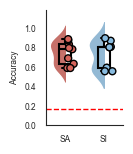

           50%       25%       75%  count
task                                     
SA    0.783333  0.633333  0.833333    9.0
SI    0.804167  0.590000  0.808333    9.0
SI vs SA: Statistic = 13.0000, p-value = 0.3008
SI vs Chance: Statistic = 81.0000, p-value = 0.0003
SA vs Chance: Statistic = 81.0000, p-value = 0.0003


In [3]:
band = 'beta1'
group = 'sig_elecs'
param = 'Accuracy'
sheet_name="Fig. 5i"

source_df = pd.read_excel(
    clean_data_path + "/Source_Data.xlsx",
    sheet_name=sheet_name
)

mean_acc_df = source_df.copy()

acc_violin_plot(band, group, mean_acc_df, param, sheet_name)

# Ext. Fig. 9a

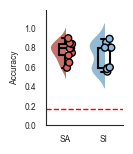

           50%   25%     75%  count
task                               
SA    0.791667  0.72  0.8375    9.0
SI    0.800000  0.59  0.8000    9.0
SI vs SA: Statistic = 11.0000, p-value = 0.2031
SI vs Chance: Statistic = 81.0000, p-value = 0.0003
SA vs Chance: Statistic = 81.0000, p-value = 0.0003


In [4]:
band = 'high_gamma'
group = 'sig_elecs'
param = 'Accuracy'
sheet_name="Ext. Fig. 9a_hg"

source_df = pd.read_excel(
    clean_data_path + "/Source_Data.xlsx",
    sheet_name=sheet_name
)

mean_acc_df = source_df.copy()

acc_violin_plot(band, group, mean_acc_df, param, sheet_name)

# Ext. Fig. 8d

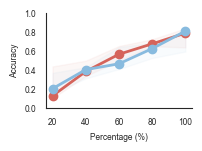

Summary statistics for each task and percentage

SA
------------------------------------------------------------
Percent  n      Q1       Median   Q3       IQR     
------------------------------------------------------------
20       9      0.100    0.125    0.433    0.333   
40       9      0.333    0.381    0.494    0.160   
60       9      0.494    0.561    0.648    0.153   
80       9      0.646    0.671    0.719    0.073   
100      9      0.633    0.783    0.833    0.200   

SI
------------------------------------------------------------
Percent  n      Q1       Median   Q3       IQR     
------------------------------------------------------------
20       9      0.150    0.200    0.367    0.217   
40       9      0.308    0.400    0.425    0.117   
60       9      0.406    0.461    0.637    0.232   
80       9      0.522    0.621    0.679    0.157   
100      9      0.590    0.804    0.808    0.218   


In [5]:
# =====================================================
# Read the Source Data workbook.
# =====================================================

sheet_name = "Ext. Fig. 8d"

percent_df = pd.read_excel(
    clean_data_path + "/Source_Data.xlsx",
    sheet_name=sheet_name
)

band = "beta1"
group = "sig_elecs"

# Select data for the specified frequency band.
percent_df = percent_df[
    percent_df["band"] == band
].copy()

# =====================================================
# Plot accuracy as a function of the electrode percentage.
# =====================================================

plt.figure(figsize=(2, 1.5))

# Extract the unique electrode percentages.
unique_percents = sorted(percent_df["percent"].unique())

tasks = ["SA", "SI"]

colors = {
    "SA": "#D5645B",
    "SI": "#88BBDF"
}

# Store summary statistics for reporting.
stats_results = {}

# =====================================================
# Calculate the median and interquartile range (IQR).
# =====================================================

for task in tasks:

    median_acc = []
    q1_acc = []
    q3_acc = []
    iqr_acc = []

    for percent in unique_percents:

        # Select one task and electrode percentage.
        percent_task_data = percent_df[
            (percent_df["percent"] == percent) &
            (percent_df["task"] == task)
        ]

        acc_values = percent_task_data["acc"].values

        # Calculate summary statistics.
        median_val = np.median(acc_values)
        q1_val = np.percentile(acc_values, 25)
        q3_val = np.percentile(acc_values, 75)
        iqr_val = q3_val - q1_val

        median_acc.append(median_val)
        q1_acc.append(q1_val)
        q3_acc.append(q3_val)
        iqr_acc.append(iqr_val)

    # Store the statistics for reporting.
    stats_results[task] = {
        "median": median_acc,
        "q1": q1_acc,
        "q3": q3_acc,
        "iqr": iqr_acc,
        "n": [
            len(
                percent_df[
                    (percent_df["percent"] == p) &
                    (percent_df["task"] == task)
                ]
            )
            for p in unique_percents
        ]
    }

    # Show the interquartile range as a shaded region.
    plt.fill_between(
        unique_percents,
        q1_acc,
        q3_acc,
        color=colors[task],
        alpha=0.05,
        label=f"{task} IQR"
    )

    # Plot the median accuracy.
    plt.plot(
        unique_percents,
        median_acc,
        marker="o",
        linestyle="-",
        linewidth=2,
        markersize=6,
        color=colors[task],
        label=f"{task} Median"
    )

# =====================================================
# Apply figure formatting.
# =====================================================

plt.ylabel("Accuracy")
plt.xlabel("Percentage (%)")

plt.xticks(unique_percents)
plt.ylim(0, 1)

plt.grid(False)
plt.tight_layout()

# Remove the top and right spines.
ax = plt.gca()
ax.spines["right"].set_visible(False)
ax.spines["top"].set_visible(False)

# Save the figure.
fig_save_path = (
    clean_data_path +
    f"figures_R3/{sheet_name}_{band}.pdf"
)

plt.savefig(
    fig_save_path,
    transparent=True,
    format="pdf",
    bbox_inches="tight"
)

plt.show()

# =====================================================
# Print the summary statistics.
# =====================================================

print("=" * 70)
print("Summary statistics for each task and percentage")
print("=" * 70)

for task in tasks:

    print(f"\n{task}")
    print("-" * 60)
    print(
        f"{'Percent':<8} "
        f"{'n':<6} "
        f"{'Q1':<8} "
        f"{'Median':<8} "
        f"{'Q3':<8} "
        f"{'IQR':<8}"
    )
    print("-" * 60)

    for i, percent in enumerate(unique_percents):

        stats = stats_results[task]

        print(
            f"{percent:<8} "
            f"{stats['n'][i]:<6} "
            f"{stats['q1'][i]:<8.3f} "
            f"{stats['median'][i]:<8.3f} "
            f"{stats['q3'][i]:<8.3f} "
            f"{stats['iqr'][i]:<8.3f}"
        )

# Ext. Fig. 9a, SA and SI tasks

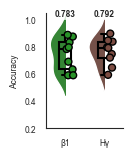


Descriptive statistics
beta1: median=0.783, Q1=0.633, Q3=0.833, n=9
high_gamma: median=0.792, Q1=0.720, Q3=0.838, n=9

Pairwise Wilcoxon signed-rank test
beta1 vs high_gamma: p=0.2031


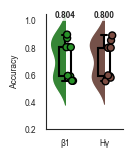


Descriptive statistics
beta1: median=0.804, Q1=0.590, Q3=0.808, n=9
high_gamma: median=0.800, Q1=0.590, Q3=0.800, n=9

Pairwise Wilcoxon signed-rank test
beta1 vs high_gamma: p=0.4961


In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import seaborn as sns

from scipy.stats import wilcoxon
from statsmodels.stats.multitest import multipletests
import itertools

# ======================================================
# Define the analysis parameters.
# ======================================================

plt.rcdefaults()
plt.rcParams["font.family"] = "Arial"
plt.rcParams["font.size"] = 6

band_order = ["beta1", "high_gamma"]
x_tick = ["β1", "Hγ"]

palette = {
    "beta1": "#289228",
    "high_gamma": "#7c4c42"
}

# ======================================================
# Define the plotting function.
# ======================================================

def multi_band_comparison(mean_acc_df,
                          fig_save_path,
                          figsize=(1,1.5)):

    plt.figure(figsize=figsize)

    sns.set_style("white")

    ax = sns.violinplot(
        data=mean_acc_df,
        x="band",
        y="acc",
        order=band_order,
        palette=palette,
        dodge=False,
        scale="width",
        inner=None,
        linewidth=1
    )

    sns.despine()

    plt.legend([], [], frameon=False)

    plt.ylim(0.2,1.05)

    # --------------------------------------------------
    # Draw the half-violin distribution.
    # --------------------------------------------------

    for violin in ax.collections:

        bbox = violin.get_paths()[0].get_extents()

        x0, y0, width, height = bbox.bounds

        violin.set_clip_path(
            Rectangle(
                (x0, y0),
                width/2,
                height,
                transform=ax.transData
            )
        )

        violin.set_edgecolor(None)

    # --------------------------------------------------
    # Overlay the boxplot.
    # --------------------------------------------------

    sns.boxplot(
        data=mean_acc_df,
        x="band",
        y="acc",
        order=band_order,
        saturation=1,
        showfliers=False,
        width=0.3,
        ax=ax,
        boxprops={
            "zorder":3,
            "facecolor":"none",
            "edgecolor":"black"
        },
        whiskerprops={"color":"black"},
        capprops={"color":"black"},
        medianprops={"color":"black"}
    )

    # --------------------------------------------------
    # Overlay individual data points.
    # --------------------------------------------------

    old_len = len(ax.collections)

    sns.stripplot(
        data=mean_acc_df,
        x="band",
        y="acc",
        order=band_order,
        palette=palette,
        dodge=False,
        size=5,
        edgecolor="black",
        linewidth=1,
        ax=ax
    )

    for dots in ax.collections[old_len:]:

        dots.set_offsets(
            dots.get_offsets()+np.array([0.12,0])
        )

    # --------------------------------------------------
    # Add the median-value label.
    # --------------------------------------------------

    for i,band in enumerate(band_order):

        median=np.median(
            mean_acc_df.loc[
                mean_acc_df.band==band,
                "acc"
            ]
        )

        ax.text(
            i,
            1.01,
            f"{median:.3f}",
            ha="center",
            va="bottom",
            fontsize=6,
            fontweight="bold",
            bbox=dict(
                boxstyle="round,pad=0.2",
                facecolor="white",
                alpha=0.8,
                edgecolor="none"
            )
        )

    ax.set_ylabel("Accuracy")
    ax.set_xlabel("")
    ax.set_xticklabels(x_tick)

    if ax.get_legend() is not None:
        ax.get_legend().remove()

    plt.savefig(
        fig_save_path,
        dpi=300,
        transparent=True,
        bbox_inches="tight"
    )

    plt.show()

    # ==================================================
    # Calculate statistical tests.
    # ==================================================

    print("\nDescriptive statistics")

    for band in band_order:

        values=mean_acc_df.loc[
            mean_acc_df.band==band,
            "acc"
        ]

        median=np.median(values)
        q1,q3=np.percentile(values,[25,75])

        print(
            f"{band}: "
            f"median={median:.3f}, "
            f"Q1={q1:.3f}, "
            f"Q3={q3:.3f}, "
            f"n={len(values)}"
        )

    print("\nPairwise Wilcoxon signed-rank test")

    pivot_df=mean_acc_df.pivot(
        index="HS",
        columns="band",
        values="acc"
    )

    raw_p=[]

    pairs=list(
        itertools.combinations(
            band_order,
            2
        )
    )

    for band1,band2 in pairs:

        valid=pivot_df[
            [band1,band2]
        ].dropna()

        stat,p=wilcoxon(
            valid[band1],
            valid[band2]
        )

        raw_p.append(p)

        print(
            f"{band1} vs {band2}: "
            f"p={p:.4f}"
        )

# ======================================================
# Extended Data Fig. 9a, SA condition.
# ======================================================

sheet_name="Ext. Fig. 9a_SA"

mean_acc_df=pd.read_excel(
    clean_data_path+"/Source_Data.xlsx",
    sheet_name=sheet_name
)

multi_band_comparison(
    mean_acc_df,
    clean_data_path+f"/figures_R3/{sheet_name}.pdf"
)


# ======================================================
# Extended Data Fig. 9a, SI condition.
# ======================================================

sheet_name="Ext. Fig. 9a_SI"

mean_acc_df=pd.read_excel(
    clean_data_path+"/Source_Data.xlsx",
    sheet_name=sheet_name
)

multi_band_comparison(
    mean_acc_df,
    clean_data_path+f"/figures_R3/{sheet_name}.pdf"
)

In [7]:
from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests
import itertools
from scipy.stats import wilcoxon

def multi_group_comparison(task, band, figsize, fig_save_path, group_order, x_tict):
    print()
    print(task, band)

    palette = sns.color_palette("PiYG")
    iris = mean_acc_df
    order = group_order

    plt.figure(figsize=figsize)
    sns.set_style("white")
    ax = sns.violinplot(
        x="group",
        y="acc",
        data=iris,
        order=order,
        dodge=False,
        palette=palette,
        scale="width",
        inner=None,
        linewidth=1,
    )

    sns.despine()
    plt.legend([], [], frameon=False)
    plt.ylim(-0.2, 1.02)

    for violin in ax.collections:
        bbox = violin.get_paths()[0].get_extents()
        x0, y0, width, height = bbox.bounds
        violin.set_clip_path(
            plt.Rectangle(
                (x0, y0),
                width / 2,
                height,
                transform=ax.transData,
            )
        )
        violin.set_edgecolor(None)

    sns.boxplot(
        x="group",
        y="acc",
        data=iris,
        order=order,
        saturation=1,
        showfliers=False,
        width=0.3,
        ax=ax,
        boxprops={
            "zorder": 3,
            "facecolor": "none",
            "edgecolor": "black",
        },
        whiskerprops={"color": "black"},
        capprops={"color": "black"},
        medianprops={"color": "black"},
    )

    old_len_collections = len(ax.collections)

    sns.stripplot(
        x="group",
        y="acc",
        data=iris,
        order=order,
        palette=palette,
        dodge=False,
        ax=ax,
        size=5,
        edgecolor="black",
        linewidth=1,
    )

    for dots in ax.collections[old_len_collections:]:
        dots.set_offsets(dots.get_offsets() + np.array([0.12, 0]))

    medians = []
    for group in group_order:
        group_data = iris[iris["group"] == group]["acc"]
        median_val = np.median(group_data)
        medians.append(median_val)

    for i, (median_val, group) in enumerate(zip(medians, group_order)):
        ax.text(
            i,
            1.01,
            f"{median_val:.3f}",
            ha="center",
            va="bottom",
            fontsize=6,
            fontweight="bold",
            bbox=dict(
                boxstyle="round,pad=0.2",
                facecolor="white",
                alpha=0,
                edgecolor="none",
            ),
        )

    sns.despine()
    plt.legend([], [], frameon=False)
    plt.ylim(0.2, 1.05)

    ax.set_ylabel("Accuracy")
    ax.set_xlabel("")
    ax.get_legend().remove()

    ticks = np.arange(len(order))
    ax.set_xticks(ticks + 0.2)
    ax.set_xticklabels(x_tict, rotation=45, ha="right")

    plt.savefig(
        fig_save_path,
        transparent=True,
        format="pdf",
        bbox_inches="tight",
    )
    plt.show()

    for group in group_order:
        data = iris[iris["group"] == group]["acc"]
        if len(data) > 0:
            median = np.median(data)
            q1, q3 = np.percentile(data, [25, 75])
            print(
                f"{group}: median = {median:.3f}, "
                f"IQR = [{q1:.3f}, {q3:.3f}], n = {len(data)}"
            )

    print("\nWilcoxon signed-rank test:")

    pairs = list(itertools.combinations(group_order, 2))
    p_values = []

    for group1, group2 in pairs:
        sub_df = iris.pivot_table(
            index="HS",
            columns="group",
            values="acc",
        )

        if group1 in sub_df.columns and group2 in sub_df.columns:
            paired_df = sub_df[[group1, group2]].dropna()
            data1 = paired_df[group1]
            data2 = paired_df[group2]

            if len(data1) > 0:
                stat, p = wilcoxon(data1, data2)
                p_values.append(p)

                sig = (
                    "***"
                    if p < 0.001
                    else "**"
                    if p < 0.01
                    else "*"
                    if p < 0.05
                    else "ns"
                )

                print(f"{group1} vs {group2}: p = {p:.4f} {sig}")

    if p_values:
        _, p_fdr, _, _ = multipletests(
            p_values,
            method="fdr_bh",
        )

        print("\nFDR-corrected:")

        for i, (group1, group2) in enumerate(pairs):
            sig_fdr = (
                "***"
                if p_fdr[i] < 0.001
                else "**"
                if p_fdr[i] < 0.01
                else "*"
                if p_fdr[i] < 0.05
                else "ns"
            )

            print(
                f"{group1} vs {group2}: "
                f"p_FDR = {p_fdr[i]:.4f} {sig_fdr}"
            )


SA beta1


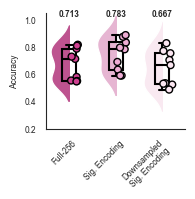

all_elecs: median = 0.713, IQR = [0.553, 0.787], n = 9
sig_elecs: median = 0.783, IQR = [0.633, 0.833], n = 9
downsample_sig_elecs: median = 0.667, IQR = [0.530, 0.754], n = 9

Wilcoxon signed-rank test:
all_elecs vs sig_elecs: p = 0.0039 **
all_elecs vs downsample_sig_elecs: p = 0.0742 ns
sig_elecs vs downsample_sig_elecs: p = 0.0039 **

FDR-corrected:
all_elecs vs sig_elecs: p_FDR = 0.0059 **
all_elecs vs downsample_sig_elecs: p_FDR = 0.0742 ns
sig_elecs vs downsample_sig_elecs: p_FDR = 0.0059 **



SI beta1


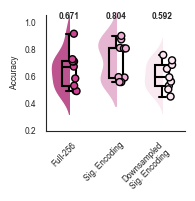

all_elecs: median = 0.671, IQR = [0.530, 0.708], n = 9
sig_elecs: median = 0.804, IQR = [0.590, 0.808], n = 9
downsample_sig_elecs: median = 0.592, IQR = [0.530, 0.683], n = 9

Wilcoxon signed-rank test:
all_elecs vs sig_elecs: p = 0.0195 *
all_elecs vs downsample_sig_elecs: p = 0.1641 ns
sig_elecs vs downsample_sig_elecs: p = 0.0078 **

FDR-corrected:
all_elecs vs sig_elecs: p_FDR = 0.0293 *
all_elecs vs downsample_sig_elecs: p_FDR = 0.1641 ns
sig_elecs vs downsample_sig_elecs: p_FDR = 0.0234 *


In [8]:
sheet_dict = {
    "SA": "Ext. Fig. 8b",
    "SI": "Ext. Fig. 8c"
}

group_order = [
    "all_elecs",
    "sig_elecs",
    "downsample_sig_elecs"
]

x_tick = [
    "Full-256",
    "Sig. Encoding",
    "Downsampled\nSig. Encoding"
]

for task in ["SA", "SI"]:

    sheet_name = sheet_dict[task]

    mean_acc_df = pd.read_excel(
        clean_data_path + "/Source_Data.xlsx",
        sheet_name=sheet_name
    )

    multi_group_comparison(
        task=task,
        band="beta1",
        figsize=(1.8, 1.5),
        fig_save_path=clean_data_path + f"/figures_R3/{sheet_name}.pdf",
        group_order=group_order,
        x_tict=x_tick
    )

# Fig. 5j and Extended Data Fig. 9b (high gamma)

Fig. 5j --- beta1


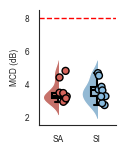

           50%       25%       75%  count
task                                     
SA    3.253145  3.133944  3.471705    9.0
SI    3.612477  3.244195  3.829475    9.0
SI vs SA: Statistic = 17.0000, p-value = 0.5703
SA vs 8: Statistic = 0.0000, p-value = 0.0039
SI vs 8: Statistic = 0.0000, p-value = 0.0039

Ext. Fig. 9b_hg --- high_gamma


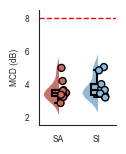

           50%       25%       75%  count
task                                     
SA    3.462507  3.280889  3.625843    9.0
SI    3.639367  3.326101  3.992027    9.0
SI vs SA: Statistic = 6.0000, p-value = 0.0547
SA vs 8: Statistic = 0.0000, p-value = 0.0039
SI vs 8: Statistic = 0.0000, p-value = 0.0039



In [9]:
sheet_dict = {
    'beta1':"Fig. 5j",
    'high_gamma':"Ext. Fig. 9b_hg"
}

for band in sheet_dict.keys():
    sheet_name = sheet_dict[band]
    print(sheet_name,'---', band)
    source_df = pd.read_excel(
        clean_data_path + "/Source_Data.xlsx",
        sheet_name=sheet_name
    )
    
    mean_acc_df = source_df.rename(columns={
        "Participant": "HS",
        "Task": "task",
        "Band": "band",
        "MCD (dB)": "acc",
        "Group": "group"
    })
    
    plt.figure(figsize=(1, 1.5))
    sns.set_style("white")
    
    iris = mean_acc_df
    
    color_dict = {
        "SA": "#D5645B",
        "SI": "#88BBDF"
    }
    
    ax = sns.violinplot(
        x="task",
        y="acc",
        data=iris,
        dodge=False,
        palette=color_dict,
        scale="width",
        inner=None,
        linewidth=1,
        edgecolor="black"
    )
    
    sns.despine()
    plt.legend([], [], frameon=False)
    plt.ylim(1.5, 8.5)
    
    for violin in ax.collections:
        bbox = violin.get_paths()[0].get_extents()
        x0, y0, width, height = bbox.bounds
        violin.set_clip_path(
            plt.Rectangle(
                (x0, y0),
                width / 2,
                height,
                transform=ax.transData,
            )
        )
        violin.set_edgecolor(None)
    
    sns.boxplot(
        x="task",
        y="acc",
        data=iris,
        saturation=1,
        showfliers=False,
        width=0.3,
        ax=ax,
        boxprops={
            "zorder": 3,
            "facecolor": "none",
            "edgecolor": "black"
        },
        whiskerprops={"color": "black"},
        capprops={"color": "black"},
        medianprops={"color": "black"}
    )
    
    old_len_collections = len(ax.collections)
    
    sns.stripplot(
        x="task",
        y="acc",
        data=iris,
        palette=color_dict,
        dodge=False,
        ax=ax,
        size=5,
        edgecolor="black",
        linewidth=1
    )
    
    for dots in ax.collections[old_len_collections:]:
        dots.set_offsets(dots.get_offsets() + np.array([0.12, 0]))
    
    ax.set_ylabel("MCD (dB)")
    ax.set_xlabel("")
    
    plt.axhline(
        y=8,
        color="red",
        linestyle="--",
        linewidth=1
    )
    
    plt.savefig(
        path + f"figures_R3/{sheet_name}.pdf",
        transparent=True,
        format="pdf",
        bbox_inches="tight"
    )
    
    plt.show()
    
    task_stats = mean_acc_df.groupby("task")["acc"].describe()
    
    print(task_stats[["50%", "25%", "75%", "count"]])
    
    covert_acc = mean_acc_df.loc[
        mean_acc_df["task"] == "SI",
        "acc"
    ]
    
    overt_acc = mean_acc_df.loc[
        mean_acc_df["task"] == "SA",
        "acc"
    ]
    
    stat, p_value = wilcoxon(covert_acc, overt_acc)
    print(f"SI vs SA: Statistic = {stat:.4f}, p-value = {p_value:.4f}")
    
    stat_sa, p_sa = wilcoxon(overt_acc - 8)
    print(f"SA vs 8: Statistic = {stat_sa:.4f}, p-value = {p_sa:.4f}")
    
    stat_si, p_si = wilcoxon(covert_acc - 8)
    print(f"SI vs 8: Statistic = {stat_si:.4f}, p-value = {p_si:.4f}")
    print('')

In [10]:
from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests
import itertools
from scipy.stats import wilcoxon

def multi_band_comparison_MCD(task, group, figsize, fig_save_path, band_order, x_tict):
    print()
    print(task, group)

    palette = ["#289228", "#7c4c42", "orange"]

    iris = mean_acc_df
    order = band_order

    plt.figure(figsize=figsize)
    sns.set_style("white")

    ax = sns.violinplot(
        x="band",
        y="acc",
        data=iris,
        order=order,
        dodge=False,
        palette=palette,
        scale="width",
        inner=None,
        linewidth=1
    )

    for violin in ax.collections:
        bbox = violin.get_paths()[0].get_extents()
        x0, y0, width, height = bbox.bounds
        violin.set_clip_path(
            plt.Rectangle((x0, y0), width / 2, height, transform=ax.transData)
        )
        violin.set_edgecolor(None)

    sns.boxplot(
        x="band",
        y="acc",
        data=iris,
        order=order,
        saturation=1,
        showfliers=False,
        width=0.3,
        ax=ax,
        boxprops={"zorder": 3, "facecolor": "none", "edgecolor": "black"},
        whiskerprops={"color": "black"},
        capprops={"color": "black"},
        medianprops={"color": "black"},
    )

    old_len_collections = len(ax.collections)

    sns.stripplot(
        x="band",
        y="acc",
        data=iris,
        order=order,
        palette=palette,
        dodge=False,
        ax=ax,
        size=5,
        edgecolor="black",
        linewidth=1,
    )

    for dots in ax.collections[old_len_collections:]:
        dots.set_offsets(dots.get_offsets() + np.array([0.12, 0]))

    medians = []
    for band in band_order:
        group_data = iris[iris["band"] == band]["acc"]
        medians.append(np.median(group_data))

    for i, (median_val, band) in enumerate(zip(medians, band_order)):
        ax.text(
            i,
            6,
            f"{median_val:.3f}",
            ha="center",
            va="bottom",
            fontsize=6,
            fontweight="bold",
            bbox=dict(
                boxstyle="round,pad=0.2",
                facecolor="white",
                alpha=0.8,
                edgecolor="none",
            ),
        )

    sns.despine()
    plt.legend([], [], frameon=False)
    plt.ylim(1.5, 8.5)

    ax.set_ylabel("MCD (dB)")
    ax.set_xlabel("")
    ax.get_legend().remove()
    ax.set_xticklabels(x_tict)

    plt.savefig(
        fig_save_path,
        transparent=True,
        format="pdf",
        bbox_inches="tight",
    )
    plt.show()

    print("\n--- Descriptive Statistics ---")

    for band in band_order:
        data = iris[iris["band"] == band]["acc"]
        if len(data) > 0:
            median = np.median(data)
            q1, q3 = np.percentile(data, [25, 75])
            print(
                f"{band}: median = {median:.3f}, "
                f"IQR = [{q1:.3f}, {q3:.3f}], "
                f"n = {len(data)}"
            )

    print("\n--- Pairwise Comparisons (Wilcoxon signed-rank test) ---")

    pairs = list(itertools.combinations(band_order, 2))
    p_values = []

    pivot_df = mean_acc_df.pivot(index="HS", columns="band", values="acc")

    for band1, band2 in pairs:
        if band1 in pivot_df.columns and band2 in pivot_df.columns:
            valid = pivot_df[[band1, band2]].dropna()
            if len(valid) > 0:
                stat, p = wilcoxon(
                    valid[band1],
                    valid[band2],
                    alternative="two-sided",
                )
                p_values.append(p)

                sig = (
                    "***" if p < 0.001 else
                    "**" if p < 0.01 else
                    "*" if p < 0.05 else
                    "ns"
                )

                print(f"  {band1} vs {band2}: p = {p:.4f} {sig}")

# Ext. Fig. 9b, SA and SI tasks


SA sig_elecs


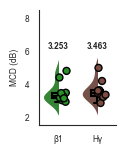


--- Descriptive Statistics ---
b1: median = 3.253, IQR = [3.134, 3.472], n = 9
hg: median = 3.463, IQR = [3.281, 3.626], n = 9

--- Pairwise Comparisons (Wilcoxon signed-rank test) ---
  b1 vs hg: p = 0.2500 ns



SI sig_elecs


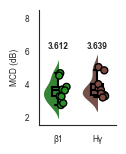


--- Descriptive Statistics ---
b1: median = 3.612, IQR = [3.244, 3.829], n = 9
hg: median = 3.639, IQR = [3.326, 3.992], n = 9

--- Pairwise Comparisons (Wilcoxon signed-rank test) ---
  b1 vs hg: p = 0.0117 *


In [11]:
group = 'sig_elecs'
for task in ['SA','SI']:
    sheet_name = f"Ext. Fig. 9b_{task}"
    source_df = pd.read_excel(
        clean_data_path + "/Source_Data.xlsx",
        sheet_name=sheet_name
    )
    
    mean_acc_df = source_df.rename(columns={
        "Subject": "HS",
        "Task": "task",
        "Band": "band",
        "MCD (dB)": "acc"
    })

    band_order = ['b1','hg']
    x_tict = ['β1','Hγ']
    figsize=(1, 1.5)
    
    fig_save_path = (
    path +
    f"figures_R3/{sheet_name}.pdf"
)
    multi_band_comparison_MCD(task, group, figsize, fig_save_path, band_order, x_tict)

    